# Test de blancura
La prueba de Box-Pierce-Ljung considera como Hipótesis nula (H0) los
residuos son no correlacionados contra la hipótesis alternativa (H1) los residuos tienen correlación. El estadístico de prueba Q depende de la función de autocorrelación y tiene una distribución asintótica chi-cuadrado.

# Recordar instalar librería

In [ ]:
!pip install darts


# Cargar librerías

In [1]:
import numpy as np
from darts import TimeSeries
from darts.datasets import AirPassengersDataset
from darts.models import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt



<Axes: xlabel='Month'>

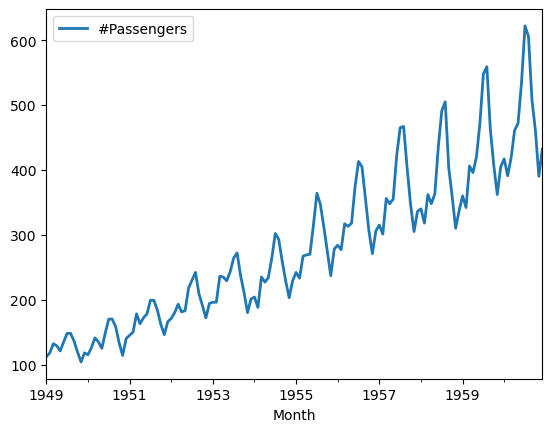

In [2]:
series = AirPassengersDataset().load()
series.plot()


#Aplicar modelo de suavizamiento exponencial
El objetivo es verificar si los residuos son un ruido blanco

<Axes: xlabel='Month'>

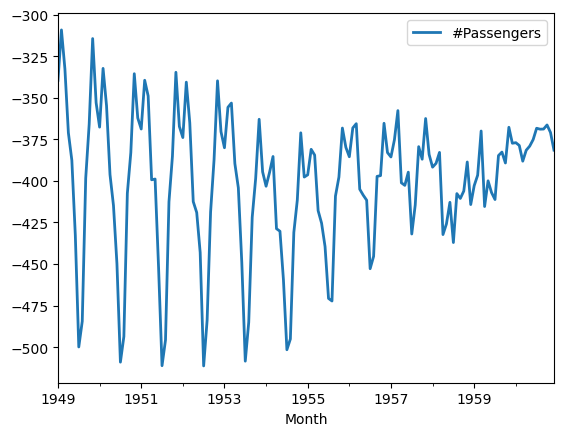

In [3]:
model = ExponentialSmoothing()
model.fit(series)
forecast = model.predict(len(series))
residuals = series - forecast
residuals.plot()


# Test de Box-Pierce-Ljung

In [4]:
ljungbox_results = acorr_ljungbox(residuals.values(), lags=10, return_df=True)
print(ljungbox_results)


       lb_stat     lb_pvalue
1    74.994817  4.719513e-18
2    89.873034  3.050132e-20
3    89.929931  2.267812e-19
4   105.034384  8.328497e-22
5   137.816781  5.207835e-28
6   169.361428  6.143679e-34
7   196.996661  4.963229e-39
8   207.119267  2.016896e-40
9   207.176382  1.035001e-39
10  219.754019  1.203345e-41


# Resultados para un ruido blanco

<Axes: xlabel='time'>

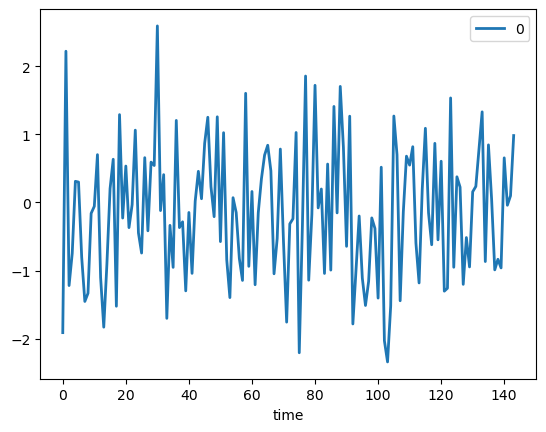

In [5]:
white_noise = TimeSeries.from_values(np.random.randn(144))
white_noise.plot()


In [6]:
ljungbox_white_noise = acorr_ljungbox(white_noise.values(), lags=10, return_df=True)
print(ljungbox_white_noise)


     lb_stat  lb_pvalue
1   0.586255   0.443871
2   0.588047   0.745259
3   0.612078   0.893662
4   0.834260   0.933797
5   0.871831   0.972227
6   1.795055   0.937550
7   1.937250   0.963232
8   2.022229   0.980323
9   2.664388   0.976131
10  2.985271   0.981769
